Importing Libraries

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the Data

In [212]:
df=pd.read_csv("urban_rental_price.csv")

Checking shape, columns and data types 

In [213]:
df.head()      # Top 5 rows

,listing_date,city,locality,locality_tier,property_type,bedrooms,area_sqft,age_of_property,furnishing_status,floor_category,parking,tenant_preference,amenity_score,rent_price
0,16-09-2019,Bangalore,Whitefield,Mid-Range,Independent House,4,2058.1,3.6,Semi-Furnished,Mid (4-7),2-Wheeler Only,Any,9,82800
1,04-02-2020,Mumbai,Thane,Budget,Apartment,1,846.0,3.1,Semi-Furnished,Mid (4-7),No Parking,Company Lease,4,25400
2,07-09-2023,Bangalore,Indiranagar,Budget,Studio,1,250.0,22.2,Fully Furnished,Low (1-3),No Parking,Bachelor,6,12800
3,29-04-2023,Bangalore,Whitefield,Budget,Apartment,4,1604.5,13.3,Unfurnished,Mid (4-7),4-Wheeler Only,Company Lease,7,28700
4,31-07-2022,Bangalore,HSR Layout,Mid-Range,Apartment,2,574.5,12.1,Semi-Furnished,High (8-15),No Parking,Company Lease,1,32600


In [214]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   listing_date       250000 non-null  str    
 1   city               250000 non-null  str    
 2   locality           250000 non-null  str    
 3   locality_tier      250000 non-null  str    
 4   property_type      250000 non-null  str    
 5   bedrooms           250000 non-null  int64  
 6   area_sqft          250000 non-null  float64
 7   age_of_property    245000 non-null  float64
 8   furnishing_status  242500 non-null  str    
 9   floor_category     250000 non-null  str    
 10  parking            246250 non-null  str    
 11  tenant_preference  250000 non-null  str    
 12  amenity_score      250000 non-null  int64  
 13  rent_price         250000 non-null  int64  
dtypes: float64(2), int64(3), str(9)
memory usage: 26.7 MB


Checking Null Values

In [215]:
df.isnull().sum()       # 3 columns have Null Values

listing_date            0
city                    0
locality                0
locality_tier           0
property_type           0
bedrooms                0
area_sqft               0
age_of_property      5000
furnishing_status    7500
floor_category          0
parking              3750
tenant_preference       0
amenity_score           0
rent_price              0
dtype: int64

In [216]:
# We have to Replace Null values for integer type columns with Mean or Median values
# And for the column With data type as string null values will be replaced by Mode of that column

Checking Outliers in Age of property Column

<Axes: >

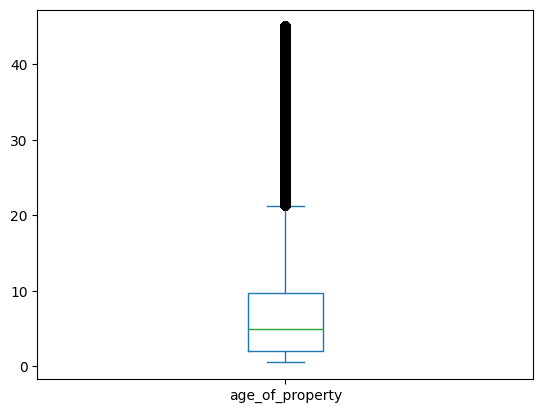

In [217]:
df["age_of_property"].plot(kind="box")   # box plot to identify Outliers

Since age of property has Outliers We will Use median() to replace Null Values

In [218]:
# Replacing Null Values with Median()
df["age_of_property"]=df["age_of_property"].fillna(df["age_of_property"].median(),inplace=True)

Now Replacing Null values for Categorical Columns with mode()

In [219]:
# Replacing Null values for Furnishing Status Column
df["furnishing_status"]=df["furnishing_status"].mode()[0]

In [220]:
# Replacing Null values for Parking Column
df["parking"]=df["parking"].mode()[0]

In [221]:
# All Null values Replaced Successfully
df.isnull().sum()

listing_date         0
city                 0
locality             0
locality_tier        0
property_type        0
bedrooms             0
area_sqft            0
age_of_property      0
furnishing_status    0
floor_category       0
parking              0
tenant_preference    0
amenity_score        0
rent_price           0
dtype: int64

Now Checking outliers or Extreme Values in Columns bedrooms,area_sqft,age_of_property,amenity_score and Rent Price

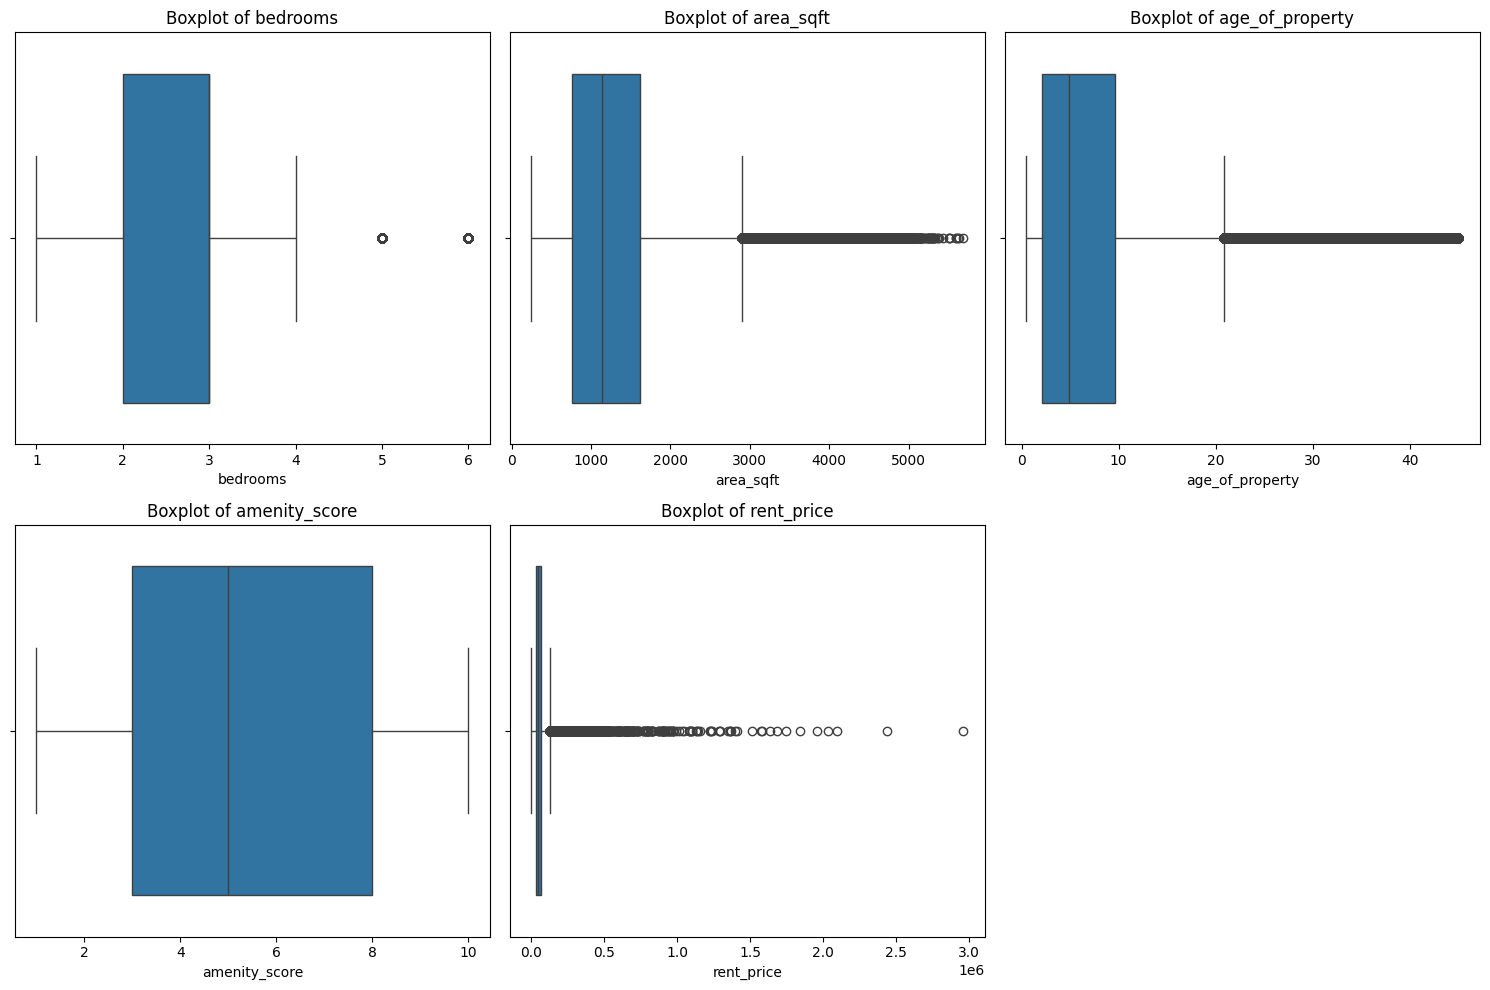

In [ ]:
# Create figure and subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Flatten axes for easier indexing
axes = axes.flatten()

# List of columns
columns = [
    "bedrooms",
    "area_sqft",
    "age_of_property",
    "amenity_score",
    "rent_price"
]

# Create boxplots
for i, col in enumerate(columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

# Remove extra empty subplot
fig.delaxes(axes[5])

# Show plots
plt.show()

As We can see from Above Plots that columns(area-sqft,age_of_property,rent_price) have Ouliers So we will be Mild Clipping the Columns

In [223]:
# Mild clipping using 99th percentile because values are Realistic

upper_limit_area = df["area_sqft"].quantile(0.99)

df["area_sqft"] = df["area_sqft"].clip(
    upper=upper_limit_area
)

In [224]:
# Mild clipping using 99th percentile because Values are Realistic

upper_limit_age = df["age_of_property"].quantile(0.99)

df["age_of_property"] = df["age_of_property"].clip(
    upper=upper_limit_age
)

In [225]:
# LOG TRANSFORMATION OF TARGET VARIABLE
import numpy as np

df["rent_price_log"] = np.log(df["rent_price"])

Checking Results After Clipping

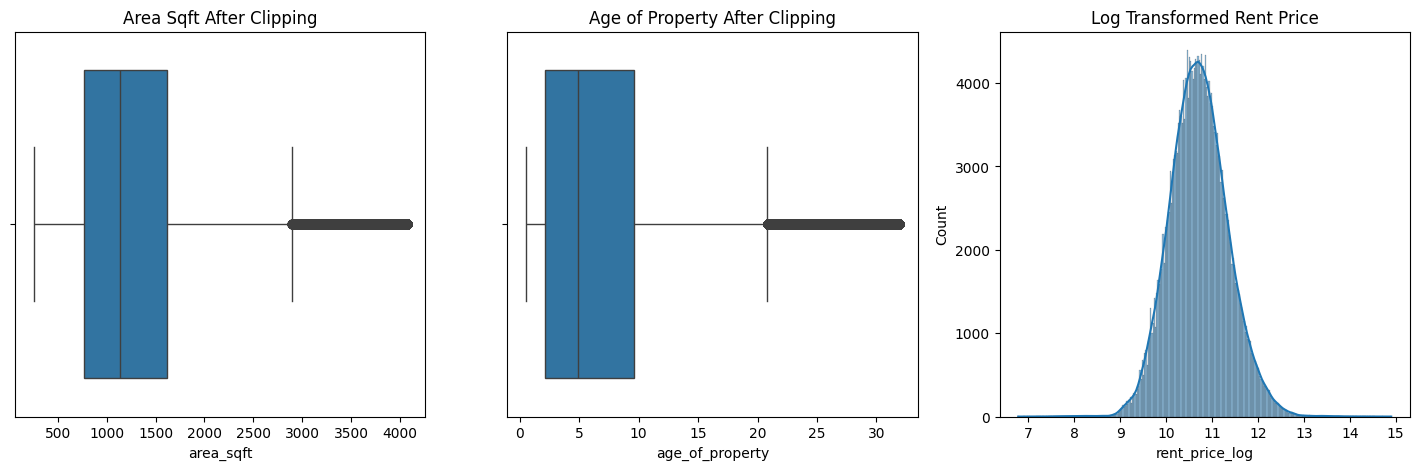

In [226]:
# Create subplot layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Boxplot: area_sqft
sns.boxplot(x=df["area_sqft"], ax=axes[0])
axes[0].set_title("Area Sqft After Clipping")

# Boxplot: age_of_property
sns.boxplot(x=df["age_of_property"], ax=axes[1])
axes[1].set_title("Age of Property After Clipping")

# Histogram: rent_price_log
sns.histplot(
    df["rent_price_log"],
    kde=True,
    ax=axes[2]
)
axes[2].set_title("Log Transformed Rent Price")

# Show plots
plt.show()

In above Plots we kept some Outliers because they were Realistic and Only Clipped Extreme Values

In [227]:
# Changing Date column in Date Data Type
df["listing_date"]=pd.to_datetime(df["listing_date"])

Dropping Column Parking and Furnishing Status because of no Variation in the Data

In [228]:
# Dropping Parking Column
df["parking"].unique()                           # Only 1 Unique Value is Available
df=df.drop(columns="parking")

# Dropping Furnishing Status Column
df["furnishing_status"].unique()                 # Only 1 Unique Value is Available
df=df.drop(columns="furnishing_status")

Now we will Encode Date type and Categorical Type Columns

In [229]:
# Categorical Columns
# Nominal - city,locality,property_type,tenant_preference
# Ordinal - locality_tier,floor_category
# Date columns
# listing_date

Encoding Date Column

In [230]:
df["year"] = df["listing_date"].dt.year
df["month"] = df["listing_date"].dt.month
df["day"] = df["listing_date"].dt.day

# Dropping Original Date column after Encoding
df=df.drop(columns="listing_date")

Encoding for Nominal Columns

In [235]:
df = pd.get_dummies(
    df,
    columns=[
        "city",
        "locality",
        "property_type",
        "tenant_preference"
    ],
    drop_first=True,dtype=np.int64
)

Ordinal Encoding

In [232]:
# Encoding for Column floor_category
df["floor_category"] = df["floor_category"].map({
    "Ground": 0,
    "Low (1-3)": 1,
    "Mid (4-7)": 2,
    "High (8-15)": 3,
    "Penthouse (16+)": 4
})

In [233]:
# Encoding for Column locality_tier 
df["locality_tier"] = df["locality_tier"].map({
    "Budget": 1,
    "Mid-Range": 2,
    "Premium": 3
})

In [236]:
df.head()

,locality_tier,bedrooms,area_sqft,age_of_property,floor_category,amenity_score,rent_price,rent_price_log,year,month,...,locality_Wakad,locality_Whitefield,locality_Yelahanka,property_type_Builder Floor,property_type_Independent House,property_type_Studio,property_type_Villa,tenant_preference_Bachelor,tenant_preference_Company Lease,tenant_preference_Family
0,2,4,2058.1,3.6,2,9,82800,11.324183,2019,9,...,0,1,0,0,1,0,0,0,0,0
1,1,1,846.0,3.1,2,4,25400,10.142504,2020,2,...,0,0,0,0,0,0,0,0,1,0
2,1,1,250.0,22.2,1,6,12800,9.457200,2023,9,...,0,0,0,0,0,1,0,1,0,0
3,1,4,1604.5,13.3,2,7,28700,10.264652,2023,4,...,0,1,0,0,0,0,0,0,1,0
4,2,2,574.5,12.1,3,1,32600,10.392068,2022,7,...,0,0,0,0,0,0,0,0,1,0


Feature Scaling for Columns ( bedrooms,area_sqft,age_of_property,amenity_score ) because of different Ranges of Data

In [237]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    "area_sqft",
    "bedrooms",
    "age_of_property",
    "amenity_score"
]

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

In [238]:
df.head()

,locality_tier,bedrooms,area_sqft,age_of_property,floor_category,amenity_score,rent_price,rent_price_log,year,month,...,locality_Wakad,locality_Whitefield,locality_Yelahanka,property_type_Builder Floor,property_type_Independent House,property_type_Studio,property_type_Villa,tenant_preference_Bachelor,tenant_preference_Company Lease,tenant_preference_Family
0,2,1.116575,0.918279,-0.502854,2,1.216743,82800,11.324183,2019,9,...,0,1,0,0,1,0,0,0,0,0
1,1,-1.307102,-0.538746,-0.579189,2,-0.523834,25400,10.142504,2020,2,...,0,0,0,0,0,0,0,0,1,0
2,1,-1.307102,-1.255178,2.336814,1,0.172397,12800,9.457200,2023,9,...,0,0,0,0,0,1,0,1,0,0
3,1,1.116575,0.373022,0.978048,2,0.520512,28700,10.264652,2023,4,...,0,1,0,0,0,0,0,0,1,0
4,2,-0.499210,-0.865107,0.794844,3,-1.568181,32600,10.392068,2022,7,...,0,0,0,0,0,0,0,0,1,0
